# Lab 1: Write a script to fit the C IV line in an SDSS-V spectrum
Rey Ramos

ASTR 3400 Dexter

In [254]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit

In [282]:
def CIV_fit(file: str):
    '''
    This function takes a fits file, reads it, and will determine if C iv is present in the
    spectrum. If present, the function will return a plot of the gaussian where the emission line
    lies on the plot. If not present, the function will print "C IV is not present"

    Input: name of the fits file as a str type
    Output: Plot or a string
    '''
   
    def gaussian(x, *p):
        A, mu, sigma, B = p
        return A*np.exp(-(x-mu)**2/(2.*sigma**2))+B

    
    f = fits.open(file)
    z = f[2].data['Z']
    z_redshift = z[0]
    wavelength = 10**f[1].data['loglam']
    flux = f[1].data['flux']
    CIV_rest = 1549
    lambda_obv =  CIV_rest * (1 + z_redshift)
    left_bound = lambda_obv - 200
    right_bound = lambda_obv + 200
    i1 = np.argmin(np.abs(wavelength - left_bound))
    i2 = np.argmin(np.abs(wavelength - right_bound))
    array_len = len(wavelength[i1:i2])
    i3 = array_len//2
    flux_error = np.std(flux[i1:i2])
    flux_median = np.median(flux[i1:i2])
   
    if lambda_obv < min(wavelength) or lambda_obv > max(wavelength):
        print("C IV is not present")

    else:
        plt.plot(wavelength[i1:i2], flux[i1:i2])
        plt.xlabel(r'wavelength (Angstrom)',fontsize=12)
        plt.ylabel(r'flux ($10^{-17}$ erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$)',fontsize=12)

        A_guess = max(flux[i1:i2])
        mu_guess = wavelength[i1:i2][np.argmax(flux[i1:i2])]
        sigma_guess = flux_error
        B_guess = min(flux[i1:i2])
        p_guess = [A_guess,mu_guess,sigma_guess,B_guess]

        fit, errors = curve_fit(gaussian, wavelength[i1:i2], flux[i1:i2], p0=p_guess)

        data_fit = gaussian(wavelength[i1:i2], *fit)

        plt.plot(wavelength[i1:i2], data_fit)

        print('best fitting parameters found by curve_fit: ',fit)

best fitting parameters found by curve_fit:  [  28.36404167 4370.31932083   42.18460565   46.56672002]


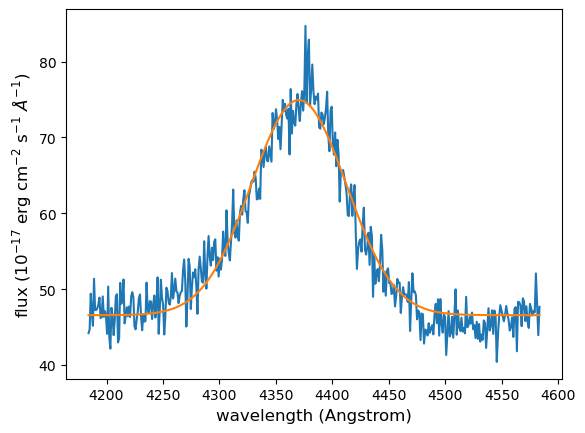

In [248]:
CIV_fit('spec-2571-54055-0017.fits')

best fitting parameters found by curve_fit:  [  14.4963603  4914.88568392   42.29042425   26.59234537]


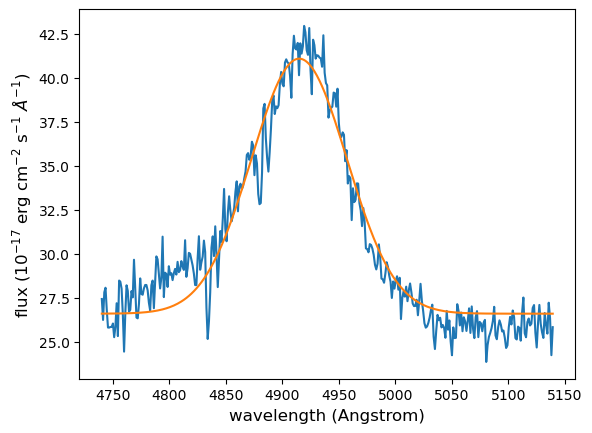

In [258]:
CIV_fit('spec-9391-58072-0898.fits')

# Discussion

The function was tested by using a fits file different from what was used in our day01/02 notebooks.
it correctly read in the file, took the pipeline z value, and calculted the observed wavelength using the rest wavelength of C IV. The plot shows the peak wavelength of the emission line and a gaussian curve was fitted to the line which gave us our best fitting parameters.

In [ ]:
A: amplitude of the emission line relative to the comtinuum, could be used to mesure the luminosity

mu: central wavelength of observed C IV can be used to measure velocity offset (almost entirely redshift)

sigma: measures characteristic velocity of the atomic gas making the line

b: continuum flux from the quasar, could be used to measure the continuum luminosity of the quasar

best fitting parameters found by curve_fit:  [1.49692050e+00 6.30580337e+03 1.00313364e+00 3.04316358e-01]


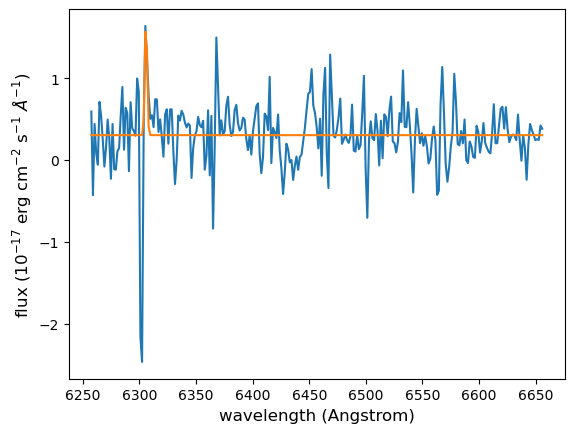

In [284]:
CIV_fit('spec-7660-57357-0435.fits')